## **1. Introduction**
The goal of this notebook is to use the trained EfficientNet model to compare different class-conditional conformal prediction methods. For this purpose, we use functions adapted from [repository](https://github.com/tiffanyding/class-conditional-conformal).

NOTA del 01/10/2025: si introduce il plot per splittate CovGap e AvgSize su due grafici.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. Libraries**

In [2]:
# Library
import re
import os
import sys
import torch
import random
import warnings
import cv2 as cv
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import plotly.subplots as sp
import plotly.graph_objects as go
import contextlib
import io


import timm
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score
import cv2
import matplotlib.pyplot as plt
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from contextlib import contextmanager

import sys
# Local Modules
sys.path.append('/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/utils')
from conformal_utils import *

## **3. General utils**

In [3]:
# Okabe–Ito palette (colorblind-safe)
#---------------------------------------------------
OKABE_ITO = {
    "blue":  "#0072B2",
    "orange":"#E69F00",
    "green": "#009E73",
    "yellow":"#F0E442",
    "red":   "#D55E00",
    "purple":"#CC79A7",
    "sky":   "#56B4E9",
    "black": "#000000"
}

def plot_covgap_avgsize_single(
    summary_df: pd.DataFrame,
    covgap_y_column: str, covgap_yerr_column: str,
    avgsize_y_column: str,  avgsize_yerr_column: str,
    model: str | None = None,                 # optional: filter a specific model if 'Model' column exists
    figure_title: str | None = None,          # optional figure title

    # y-limits (if None, computed from mean ± scale*err with padding)
    covgap_ylim=None, avgsize_ylim=None,

    # output paths
    save_path_pdf: str | None = None,
    save_path_png: str | None = None,

    # --- Layout / styling ---
    base_font: float = 9.0,       # aligned with your set_paper_style default
    tick_mult: float = 0.95,
    title_mult: float = 1.0,
    ms_cov: float = 1.6,
    ms_avg: float = 1.6,
    capsize: float = 3.2,
    capthick: float = 1.3,
    elw_color: float = 1.5,
    elw_outline: float = 2.6,
    figsize_width: float = 3.8,
    height_total: float = 4.4,
    rotate_x: int = 0,
    fontsize_xticks: float = 7,

    # single centered xlabel across the figure
    central_xlabel: bool = True,
    xlabel_text: str = "Method",
    xlabel_fontsize: float | None = None,
    xlabel_y: float = 0.02,

    # y-limit policy based on error bars
    ylim_from_errors: bool = True,
    yerr_scale_cov: float = 1.0,
    yerr_scale_avg: float = 1.0,
    ylim_pad_frac: float = 0.06,

    # --- NEW: explicit colors (Okabe–Ito defaults) ---
    col_covgap: str = "#0072B2",   # Okabe–Ito blue
    col_avgsize: str = "#009E73",  # Okabe–Ito green

    # outline color for the errorbar outline layer
    outline_color: str = "black"
):
    """
    Create a 2×1 panel for a single model with Okabe–Ito palette and print-friendly style:
      • Row 1: CovGap (outlined error bars)
      • Row 2: AvgSize (outlined error bars)

    Notes:
      - No global variables are required. Colors and style are passed or defaulted.
      - If 'set_paper_style' exists, it is used; otherwise a compact fallback style is applied.
      - If '_draw_errorbar_with_outline' exists, it is used; otherwise we fallback to ax.errorbar.
    Returns:
      fig, axs
    """

    # ---------------------------
    # Style: use user's set_paper_style if available, otherwise fallback
    # ---------------------------
    def _apply_style(fontsize=9.0, tick_mult=0.95, title_mult=1.0):
        try:
            # Use the user's custom style if defined elsewhere
            set_paper_style(fontsize=fontsize, tick_mult=tick_mult, title_mult=title_mult)  # noqa: F821
        except Exception:
            # Minimal compact fallback
            plt.rcParams.update({
                "axes.edgecolor": "#BBBBBB",
                "axes.labelweight": "bold",
                "axes.labelsize": fontsize,
                "axes.titlesize": fontsize * title_mult,
                "xtick.labelsize": fontsize * tick_mult,
                "ytick.labelsize": fontsize * tick_mult,
                "grid.color": "#EAEAEA",
                "grid.linestyle": "-",
                "grid.linewidth": 0.6,
                "legend.frameon": False,
                "axes.spines.top": False,
                "axes.spines.right": False,
                "figure.dpi": 120,
            })

    _apply_style(fontsize=base_font, tick_mult=tick_mult, title_mult=title_mult)

    # ---------------------------
    # Data selection / validation
    # ---------------------------
    df = summary_df.copy()
    if model is not None and "Model" in df.columns:
        df = df.loc[df["Model"] == model].copy()
    if "Method" not in df.columns:
        raise ValueError("summary_df must include a 'Method' column.")
    if df.empty:
        raise ValueError("No data to plot after filtering (check 'model' and input columns).")

    methods = df["Method"].tolist()
    x_pos = np.arange(len(methods), dtype=float)

    # ---------------------------
    # Helper: compute y-limits from mean ± scale*err with padding
    # ---------------------------
    def _limits_from_errors_local(d, y_col, yerr_col, scale=1.0, pad_frac=0.06, floor_zero=True):
        y = d[y_col].to_numpy()
        ye = d[yerr_col].to_numpy() if yerr_col in d.columns else np.zeros_like(y)
        lo = np.nanmin(y - scale * ye)
        hi = np.nanmax(y + scale * ye)
        if floor_zero:
            lo = max(0.0, lo)
        rng = max(1e-12, hi - lo)
        pad = pad_frac * rng
        return (lo - pad, hi + pad)

    # ---------------------------
    # Axis limits
    # ---------------------------
    if covgap_ylim is None:
        covgap_ylim = (
            _limits_from_errors_local(df, covgap_y_column, covgap_yerr_column,
                                      scale=yerr_scale_cov, pad_frac=ylim_pad_frac, floor_zero=True)
            if ylim_from_errors else None
        )
    if covgap_ylim is None:
        y = df[covgap_y_column].to_numpy()
        lo, hi = np.nanmin(y), np.nanmax(y)
        rng = max(1e-12, hi - lo)
        covgap_ylim = (max(0.0, lo - 0.15 * rng), hi + 0.15 * rng)

    if avgsize_ylim is None:
        avgsize_ylim = (
            _limits_from_errors_local(df, avgsize_y_column, avgsize_yerr_column,
                                      scale=yerr_scale_avg, pad_frac=ylim_pad_frac, floor_zero=True)
            if ylim_from_errors else None
        )
    if avgsize_ylim is None:
        y2 = df[avgsize_y_column].to_numpy()
        lo2, hi2 = np.nanmin(y2), np.nanmax(y2)
        rng2 = max(1e-12, hi2 - lo2)
        avgsize_ylim = (max(0.0, lo2 - 0.15 * rng2), hi2 + 0.15 * rng2)

    # ---------------------------
    # Build figure (2×1)
    # ---------------------------
    fig_width = max(figsize_width, 3.0)
    fig, axs = plt.subplots(2, 1, figsize=(fig_width, height_total), sharex=True)

    # Robust wrapper for outlined error bars
    def _plot_with_outline(ax, x, y, yerr, color, marker, ms):
        try:
            _draw_errorbar_with_outline(   # noqa: F821
                ax=ax, x=x, y=y, yerr=yerr, color=color, marker=marker,
                ms=ms, elw_color=elw_color, elw_outline=elw_outline,
                capsize=capsize, capthick=capthick, zorder=3,
                outline_color=outline_color
            )
        except Exception:
            # Fallback: plain errorbar
            ax.errorbar(x, y, yerr=yerr, fmt=marker, color=color,
                        markersize=ms, elinewidth=elw_color, capsize=capsize,
                        capthick=capthick, markerfacecolor="white", ecolor=color, zorder=3)

    # --- Row 1: CovGap ---
    ax_cg = axs[0]
    ax_cg.grid(True, axis="y")
    ax_cg.set_ylim(*covgap_ylim)
    y  = df[covgap_y_column].to_numpy()
    ye = df[covgap_yerr_column].to_numpy() if covgap_yerr_column in df.columns else None
    _plot_with_outline(ax_cg, x_pos, y, ye, color=col_covgap, marker="o", ms=ms_cov)
    ax_cg.set_ylabel("CovGap", color=col_covgap)

    # --- Row 2: AvgSize ---
    ax_av = axs[1]
    ax_av.grid(True, axis="y")
    ax_av.set_ylim(*avgsize_ylim)
    y2  = df[avgsize_y_column].to_numpy()
    ye2 = df[avgsize_yerr_column].to_numpy() if avgsize_yerr_column in df.columns else None
    _plot_with_outline(ax_av, x_pos, y2, ye2, color=col_avgsize, marker="s", ms=ms_avg)
    ax_av.set_ylabel("AvgSize", color=col_avgsize)

    # X ticks only on the bottom axis
    ax_av.set_xticks(x_pos)
    ax_av.set_xticklabels(methods, rotation=rotate_x, fontsize=fontsize_xticks)

    # Optional figure title (no legend in this layout)
    if figure_title:
        fig.suptitle(figure_title, fontsize=base_font * title_mult, y=0.995)

    # Tight layout and centered xlabel
    plt.tight_layout(rect=[0, 0.06 if central_xlabel else 0, 1, 0.98])
    if central_xlabel:
        fs = xlabel_fontsize if xlabel_fontsize is not None else base_font
        if hasattr(fig, "supxlabel"):
            fig.supxlabel(xlabel_text, fontsize=fs, y=xlabel_y)
        else:
            fig.text(0.5, xlabel_y, xlabel_text, ha='center', va='bottom', fontsize=fs)

    # Save to file(s) if requested
    if save_path_pdf:
        os.makedirs(os.path.dirname(save_path_pdf), exist_ok=True)
        fig.savefig(save_path_pdf, bbox_inches="tight")
    if save_path_png:
        os.makedirs(os.path.dirname(save_path_png), exist_ok=True)
        fig.savefig(save_path_png, dpi=600, bbox_inches="tight")

    return fig, axs

In [4]:
#Creates a single plot with two y-axes: one for CovGap and one for AvgSize
def plot_interval_cp(table_df, covgap_y_column, covgap_yerr_column,
                     avgsize_y_column, avgsize_yerr_column,
                     config, save_path=None, title=None):

    methods = table_df['Method']
    x_pos = range(len(methods))  # Use numeric positions for tighter spacing

    y_covgap = table_df[covgap_y_column]
    yerr_covgap = table_df[covgap_yerr_column]
    y_avgsize = table_df[avgsize_y_column]
    yerr_avgsize = table_df[avgsize_yerr_column]

    fig, ax1 = plt.subplots(figsize=(6, 4))

    # CovGap plot (left y-axis)
    line1 = ax1.errorbar(x_pos, y_covgap, yerr=yerr_covgap, marker='o', linestyle='', #linestyle='--',
                         linewidth=0.8, capsize=4, color='tab:blue', label='CovGap', elinewidth=1)
    ax1.set_ylabel('CovGap', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # AvgSize plot (right y-axis)
    ax2 = ax1.twinx()
    line2 = ax2.errorbar(x_pos, y_avgsize, yerr=yerr_avgsize, marker='s', linestyle='', #linestyle='--',
                         linewidth=0.8, capsize=4, color='tab:green', label='AvgSize', elinewidth=1)
    ax2.set_ylabel('AvgSize', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    # X-axis
    ax1.set_xlabel('Method')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(methods, rotation=0)

    # Title
    #ax1.set_title('CNN Model', fontsize=11)
    # Optional title
    if title is not None:
        ax1.set_title(title, fontsize=11)

    # Legend (top-right) with alpha
    dummy_line = ax1.plot([], [], ' ', label=r'$\alpha$ = {:.2f}'.format(config.alpha))[0]
    lines = [line1, line2, dummy_line]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right', fontsize=9)

    # Grid and layout
    ax1.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Save to PDF if path is provided
    if save_path is not None:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
        print(f"Plot saved to {save_path}")

    plt.show()

# Split 'CovGap' and 'AvgSize' columns into separate mean and standard error columns
def split_mean_se(value):
    match = re.match(r"\s*([0-9.]+)\s*\(\s*([0-9.]+)\s*\)", str(value))
    if match:
        return float(match.group(1)), float(match.group(2))
    else:
        print(f"Formato non riconosciuto: {value}")
        return None, None

def set_scores(suffix):
    global cal_scores, cal_aug_scores, test_scores

    def safe_copy(obj):
        return obj.clone() if hasattr(obj, 'clone') else obj.copy()

    cal_scores = safe_copy(globals()[f'cal_scores_{suffix}'])
    cal_aug_scores = safe_copy(globals()[f'cal_aug_scores_{suffix}'])
    test_scores = safe_copy(globals()[f'test_scores_{suffix}'])


# Function to get model predictions (softmax probabilities) from a dataloader
def get_model_probs(model, dataloader, device):
    model.eval()
    probs = []
    for images in tqdm(dataloader, total=len(dataloader)):
        images = images[0].to(device)  # Adjust if your DataLoader returns a tuple
        with torch.no_grad():
            outputs = model(images)
            outputs = outputs.softmax(dim=1).cpu().numpy()
            probs.append(outputs)
    return np.concatenate(probs)


# Valid sets shared across the codebase
VALID_SETS = {"train", "val", "test", "cal"}

# Function to generate the image path based on augmented dataset
def image_path_generation_aug(row, base_path='/wmdd811k/images'):
    """
    Generates the full image path for a given row.

    Parameters:
        row (dict or pd.Series): Contains at least 'set' and 'image' keys.
        base_path (str): Base directory where images are stored.

    Returns:
        str: Full path to the image.

    Raises:
        ValueError: If 'set' is not one of the valid options.
    """
    if row["set"] not in VALID_SETS:
        raise ValueError(f"Invalid set name: {row['set']}. Expected one of {VALID_SETS}.")
    return os.path.join(base_path, row["image"])


def image_path_generation(row, base_path='/wmdd811k/images'):
    """
    Generate the full path to an image based on the dataset split and image name.

    Parameters:
    - row (pd.Series): A row with at least 'set' and 'image' fields.
    - base_path (str): The base directory containing the image folders.

    Returns:
    - str: Full path to the image file.
    """
    subfolder = row['set']
    return os.path.join(base_path, subfolder, row['image'])

# Plot the label distribution as a bar chart
def plot_label_distribution(df, label_col='labels', title='Label Distribution',
                            figsize=(6, 4), color_palette='Set2'):
    """
    Plot a bar chart of label distribution with annotations and full grid.

    Parameters:
    - df (pd.DataFrame): DataFrame containing the label column.
    - label_col (str): Name of the column containing the labels.
    - title (str): Title of the plot.
    - figsize (tuple): Size of the figure (width, height).
    - color_palette (str or list): Color palette for the bars.
    """
    counts = df[label_col].value_counts().sort_values(ascending=False)

    plt.figure(figsize=figsize)
    ax = plt.bar(counts.index.astype(str), counts.values, color=sns.color_palette(color_palette, len(counts)))

    # Annotate each bar with its count
    for index, value in enumerate(counts.values):
        plt.text(index, value + (0.00 * counts.max()), f'{value}',
                 ha='center', va='bottom', fontsize=8)

    plt.title(title, fontsize=13)
    plt.xlabel('Labels', fontsize=10)
    plt.ylabel('Counts', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, axis='both', linestyle='--', linewidth=0.5, alpha=0.8)  # Full grid
    plt.tight_layout()
    plt.show()


## **4. CNN utils**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

def load_images(dataframe, cfg):
    """Load and preprocess grayscale images from a dataframe with progress bar."""
    images = []
    labels = []

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Loading images"):
        img_path = row['image_id']
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (cfg.input_shape[0], cfg.input_shape[1]))
        img = img.astype(np.float32)

        if cfg.normalize:
            img /= 255.0

        img = np.expand_dims(img, axis=-1)
        images.append(img)
        labels.append(row['labels'])

    return np.array(images), np.array(labels)

def get_class_weights(y_train):
    """Compute class weights to handle imbalance."""
    unique_classes = np.unique(y_train)
    class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
    return {i: weight for i, weight in zip(unique_classes, class_weights)}


# Define and compile a CNN model
def build_model(input_shape, num_classes):
    model = keras.models.Sequential([
        layers.Conv2D(64, 7, strides=(2,2), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model


def plot_history(history):
    """Plot training and validation loss and accuracy"""

    # Recupera i dati dal training
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    train_acc = history.history.get('accuracy')  # 'accuracy' per classificazione
    val_acc = history.history.get('val_accuracy')

    epochs = range(1, len(train_loss) + 1)

    # Plot della Loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    # Plot dell'Accuracy (se disponibile)
    if train_acc is not None and val_acc is not None:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
        plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title('Training and Validation Accuracy')

    plt.show()

def train_model(model, X_train, y_train, X_val, y_val, use_class_weights=True):
    class_weights = get_class_weights(y_train) if use_class_weights else None

    callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=cfg.patience, restore_best_weights=True)]

    if cfg.model_save:
        model_path = os.path.join(cfg.output_dir, "CNN_best_model.keras")
        callbacks.append(keras.callbacks.ModelCheckpoint(model_path, save_best_only=True))

    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=cfg.epochs,
                        batch_size=cfg.batch_size,
                        class_weight=class_weights,
                        callbacks=callbacks)
    plot_history(history)

    return history

def load_trained_model(model_dir, model_name):

    model_path = os.path.join(model_dir, model_name)

    if not os.path.exists(model_path):
        raise FileNotFoundError(f" Model not found: {model_path}")

    model = keras.models.load_model(model_path)
    print(f" Model successfully loaded from {model_path}")

    return model


def predict_test(model, test_dataframe, batch_size=32):
    predictions = []
    batch_images = []

    for _, row in tqdm(test_dataframe.iterrows(), total=len(test_dataframe), desc="Predizione", ncols=100):
        img_path = row['image_id']
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            predictions.append(None)
            continue

        img = cv2.resize(img, (cfg.input_shape[0], cfg.input_shape[1]))  # Resize
        img = img.astype(np.float32)  # Converti in float

        if CFG.normalize:
            img /= 255.0  # Normalizza

        img = np.expand_dims(img, axis=-1)  # Aggiungi canale (H, W, 1)
        img = np.expand_dims(img, axis=0)  # Aggiungi batch dimension (1, H, W, C)

        batch_images.append(img)

        if len(batch_images) == batch_size:
            batch_imgs = np.concatenate(batch_images, axis=0)
            batch_preds = model.predict(batch_imgs)
            predictions.extend(np.argmax(batch_preds, axis=1))
            batch_images = []  # Reset del batch

    if batch_images:
        batch_imgs = np.concatenate(batch_images, axis=0)
        batch_preds = model.predict(batch_imgs)
        predictions.extend(np.argmax(batch_preds, axis=1))

    return np.array(predictions)

def prob_predict_test(model, test_dataframe, batch_size=32):
    """Perform predictions on the test set in batches and return class probabilities."""
    predictions = []
    batch_images = []

    for _, row in tqdm(test_dataframe.iterrows(), total=len(test_dataframe), desc="Predicting", ncols=100):
        img_path = row['image_id']  # Full image path
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale

        if img is None:
            predictions.append(None)
            continue

        img = cv2.resize(img, (cfg.input_shape[0], cfg.input_shape[1]))  # Resize image
        img = img.astype(np.float32)  # Convert to float32

        if CFG.normalize:
            img /= 255.0  # Normalize pixel values to [0, 1]

        img = np.expand_dims(img, axis=-1)  # Add channel dimension (H, W, 1)
        img = np.expand_dims(img, axis=0)   # Add batch dimension (1, H, W, C)

        batch_images.append(img)

        if len(batch_images) == batch_size:
            batch_imgs = np.concatenate(batch_images, axis=0)
            batch_preds = model.predict(batch_imgs)  # Predict class probabilities
            predictions.extend(batch_preds.tolist())  # Append predictions
            batch_images = []  # Reset batch

    # Predict remaining images in the last incomplete batch
    if batch_images:
        batch_imgs = np.concatenate(batch_images, axis=0)
        batch_preds = model.predict(batch_imgs)
        predictions.extend(batch_preds.tolist())

    return np.array(predictions)  # Return array of probabilities for each image


def evaluate_model(y_true, y_pred, y_probs):
    """Compute and print evaluation metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    macro_recall = recall_score(y_true, y_pred, average='macro')
    roc_auc = roc_auc_score(y_true, y_probs, multi_class='ovr')

    print(f'Overall Accuracy: {accuracy:.5f}')
    print(f'Macro-averaged recall score: {macro_recall:.5f}')

## **5. Load data and split data**

In [6]:
# Define the base path for images
dataseet_path = '/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/'
file_name = 'WM_811k_subset.csv'

# Load dataset
df = pd.read_csv(dataseet_path + file_name, index_col=0)

# Generate full image paths by passing base_image_path to the function via lambda
df['image_id'] = df.apply(lambda row: image_path_generation(row, base_path=dataseet_path), axis=1)
df['image_type'] = 'original'
print('df size:', df.shape)
df.head(3)

df size: (10860, 8)


,wf_id,dieSize,lotid,labels,image,set,image_id,image_type
0,0,533.0,lot173,Near-full,wf_image_0.png,test,/content/drive/MyDrive/Conformal_Prediction_Re...,original
1,1,1376.0,lot45729,Edge-Loc,wf_image_1.png,val,/content/drive/MyDrive/Conformal_Prediction_Re...,original
2,2,515.0,lot36599,Center,wf_image_2.png,train,/content/drive/MyDrive/Conformal_Prediction_Re...,original


In [7]:
# Separate calibration and test sets
cal = df[df['set'] == 'cal'][['labels', 'image_id']].reset_index(drop=True)
test = df[df['set'] == 'test'][['labels', 'image_id']].reset_index(drop=True)
# Controllo del risultato
print('test size:', test.shape)
print('calib size:', cal.shape)

test size: (2172, 2)
calib size: (1477, 2)


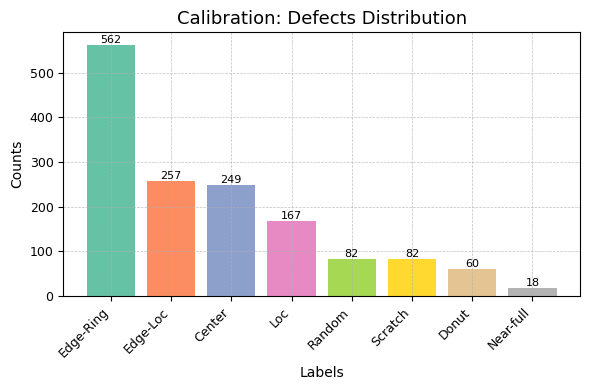

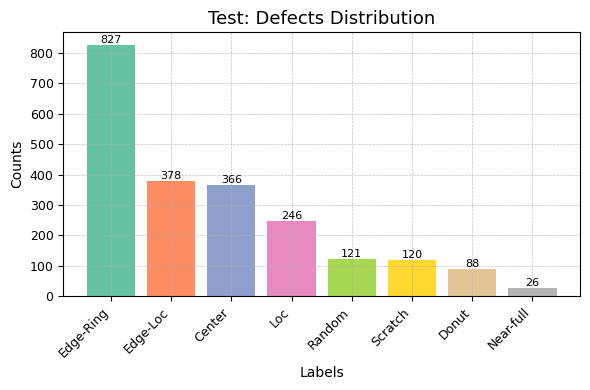

In [8]:
plot_label_distribution(cal, label_col='labels', title='Calibration: Defects Distribution')
plot_label_distribution(test, label_col='labels', title='Test: Defects Distribution')

## **6. Augmented calibration set**

In [9]:
# Base path
path = "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/dataset/dataaugmented/cal"
file_name = "calib_augmented.csv"
base_path = os.path.join(path, file_name)

# Load and preprocess dataset
dfaug = (
    pd.read_csv(base_path, index_col=0)
    .reset_index()
    .assign(set="cal", image_type="aug_std", image=lambda df: df["image_id"].map(os.path.basename))
)

# Generate full image paths using a lambda to pass base_path
dfaug["image_id"] = dfaug.apply(lambda row: image_path_generation_aug(row, path), axis=1)

dfaug.head(4)

,image_id,labels,set,image_type,image
0,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc,cal,aug_std,wf_image_10784_0.png
1,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc,cal,aug_std,wf_image_6153_1.png
2,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc,cal,aug_std,wf_image_284_2.png
3,/content/drive/MyDrive/Conformal_Prediction_Re...,Edge-Loc,cal,aug_std,wf_image_1062_3.png


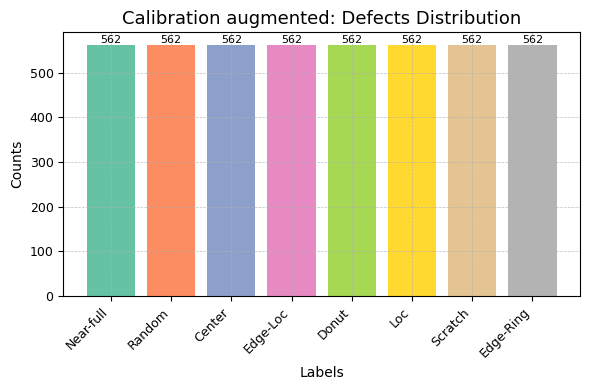

calibration augmented dataset size: (4496, 2)


In [10]:
cal_aug = dfaug[dfaug['set'] == 'cal'][['labels', 'image_id']].reset_index(drop=True)
cal_aug = pd.concat([cal, cal_aug], ignore_index=True).sample(frac=1).reset_index(drop=True)
plot_label_distribution(cal_aug, label_col='labels', title='Calibration augmented: Defects Distribution')
print('calibration augmented dataset size:', cal_aug.shape)

## **7. Prediction on test and calibration dataset**
### Configuration setup

In [11]:
class CFG:
    epochs = 200  # Reduced from 500, sufficient for CNN on 101x101 images
    patience = 20  # More balanced value to stop earlier in case of overfitting
    normalize = True
    model_save = True  # Automatically save the best model
    num_classes = 8
    input_shape = (101, 101, 1)
    batch_size = 64  # Larger batch size if possible, to speed up training
    output_dir = './'#directory to save the model
    label2int = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3,
    'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-full': 7
                                                        }
    randomize = True, #for  get_APS_scores_all function
    seed = 0         #for  get_APS_scores_all function
    n_sim = 1000
    alpha=0.01
    score = 'APS'  # method to compute scores ('APS', 'RAPS', 'STD')
    numclasses = 8
cfg = CFG()

os.makedirs(cfg.output_dir, exist_ok=True)

In [12]:
cal['labels']=cal.labels.map(cfg.label2int)
cal_aug['labels']=cal_aug.labels.map(cfg.label2int)
test['labels']=test.labels.map(cfg.label2int)

print(np.sort(cal['labels'].unique()))
print(np.sort(cal_aug['labels'].unique()))
print(np.sort(test['labels'].unique()))

[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]
[0 1 2 3 4 5 6 7]


In [13]:
model_dir = "/content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/models"
model_name =' CNN_best_model.keras'

# Load the trained model
model = load_trained_model(model_dir,'CNN_best_model.keras')

 Model successfully loaded from /content/drive/MyDrive/Conformal_Prediction_Research/Class_Conditional_CP_with_Data_Augmentation/WMDD_application/models/CNN_best_model.keras


In [ ]:
cal_probs = prob_predict_test(model, cal)
cal_aug_probs = prob_predict_test(model, cal_aug)
test_probs = prob_predict_test(model, test)

Predicting:   0%|                                                          | 0/1477 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━

Predicting:   0%|                                                          | 0/4496 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

In [ ]:
# Prepare true labels and predictions for the test set
y_true = test.labels.values
y_pred = test_probs.argmax(axis=1)

# Verify if the results from the trained model match those from the loaded model
evaluate_model(y_true, y_pred, test_probs)

## **8. Class-conformal prediction**
We compute the marginal, classwise, and clustered methods on the calibration dataset, and the classwise method on the augmented dataset.

In [ ]:
numclasses = len(cal['labels'].unique())
# prepare the different datasets
cal_labels, cal_smx = prepare_data(cal, cal_probs)
cal_aug_labels, cal_aug_smx = prepare_data(cal_aug, cal_aug_probs)
test_labels, test_smx = prepare_data(test, test_probs)

In [ ]:
cfg.alpha=0.01
results_aug = []


for i in tqdm(range(cfg.n_sim), desc="Simulazioni"):
    cfg.seed = i

    # Set the random seed for reproducibility across libraries
    np.random.seed(cfg.seed)
    #orch.manual_seed(cfg.seed)
    random.seed(cfg.seed)

    cal_scores_APS = get_APS_scores_all(cal_smx, randomize=cfg.randomize, seed=cfg.seed)
    cal_aug_scores_APS = get_APS_scores_all(cal_aug_smx, randomize=cfg.randomize, seed=cfg.seed)
    test_scores_APS = get_APS_scores_all(test_smx, randomize=cfg.randomize, seed=cfg.seed)


    cal_scores_RAPS = get_RAPS_scores_all(cal_smx, lmbda=.01, kreg=5, randomize=cfg.randomize, seed=cfg.seed)
    cal_aug_scores_RAPS = get_RAPS_scores_all(cal_aug_smx, lmbda=.01, kreg=5, randomize=cfg.randomize, seed=cfg.seed)
    test_scores_RAPS = get_RAPS_scores_all(test_smx, lmbda=.01, kreg=5, randomize=cfg.randomize, seed=cfg.seed)

    cal_scores_STD = 1 - cal_smx
    cal_aug_scores_STD = 1 - cal_aug_smx
    test_scores_STD = 1 - test_smx

    # Store the global variables required for the selected method
    if cfg.score == 'APS':
        globals()['cal_scores_APS'] = cal_scores_APS
        globals()['cal_aug_scores_APS'] = cal_aug_scores_APS
        globals()['test_scores_APS'] = test_scores_APS
    elif cfg.score == 'RAPS':
        globals()['cal_scores_RAPS'] = cal_scores_RAPS
        globals()['cal_aug_scores_RAPS'] = cal_aug_scores_RAPS
        globals()['test_scores_RAPS'] = test_scores_RAPS
    elif cfg.score == 'STD':
        globals()['cal_scores_STD'] = cal_scores_STD
        globals()['cal_aug_scores_STD'] = cal_aug_scores_STD
        globals()['test_scores_STD'] = test_scores_STD
    else:
        raise ValueError(f"Unknown score type: {cfg.score}")

    # Ora possiamo richiamare set_scores senza errori
    set_scores(cfg.score)

    with contextlib.redirect_stdout(io.StringIO()):
            _, _, marginal_coverage_metrics, marginal_set_size_metrics = standard_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha)
            _, _, classwise_coverage_metrics, classwise_set_size_metrics = classwise_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha, num_classes=numclasses)
            _, _, clustered_cov_metrics, clustered_set_size_metrics = clustered_conformal(cal_scores, cal_labels, alpha=cfg.alpha, val_scores_all=test_scores, val_labels=test_labels)
            _, _, coverage_metrics_aug, set_size_metrics_aug = classwise_conformal(cal_aug_scores, cal_aug_labels, test_scores, test_labels, alpha=cfg.alpha, num_classes=numclasses)

    results_aug.append({
            'seed': cfg.seed,
            'marginal_cov_gap': marginal_coverage_metrics['mean_class_cov_gap'],
            'marginal_set_size': marginal_set_size_metrics['mean'],
            'classwise_cov_gap': classwise_coverage_metrics['mean_class_cov_gap'],
            'classwise_set_size': classwise_set_size_metrics['mean'],
            'clust_cov_gap': clustered_cov_metrics['mean_class_cov_gap'],
            'clust_set_size': clustered_set_size_metrics['mean'],
            'class_aug_cov_gap': coverage_metrics_aug['mean_class_cov_gap'],
            'class_aug_set_size': set_size_metrics_aug['mean']
        })

    # 6. Final summary
results_df = pd.DataFrame(results_aug)


In [ ]:
# 6. Final summary
results_df = pd.DataFrame(results_aug)

def format_mean_std(series):
        return f"{series.mean():.3f} ({series.std():.4f})"

table_df = pd.DataFrame({
        "Method": ["Standard", "Classwise", "Clustered", "Augmented"],
        "CovGap": [
            format_mean_std(results_df["marginal_cov_gap"]),
            format_mean_std(results_df["classwise_cov_gap"]),
            format_mean_std(results_df["clust_cov_gap"]),
            format_mean_std(results_df["class_aug_cov_gap"]),
        ],
        "AvgSize": [
            format_mean_std(results_df["marginal_set_size"]),
            format_mean_std(results_df["classwise_set_size"]),
            format_mean_std(results_df["clust_set_size"]),
            format_mean_std(results_df["class_aug_set_size"]),
        ]
    })
table_df

In [ ]:
# Apply the parsing function to extract mean and standard error
table_df[['CovGap_mean', 'CovGap_se']] = table_df['CovGap'].apply(lambda x: pd.Series(split_mean_se(x)))
table_df[['AvgSize_mean', 'AvgSize_se']] = table_df['AvgSize'].apply(lambda x: pd.Series(split_mean_se(x)))

In [ ]:
fig, axs = plot_covgap_avgsize_single(
    summary_df=table_df,
    covgap_y_column="CovGap_mean",    covgap_yerr_column="CovGap_se",
    avgsize_y_column="AvgSize_mean",  avgsize_yerr_column="AvgSize_se",
    model=None,
    figure_title="CNN Model",   # opzionale
    rotate_x=0, fontsize_xticks=6,
    save_path_pdf=cfg.output_dir+'wm811k_cnn_intervalplot.pdf'
)
plt.show()


In [ ]:
#plot_interval_cp(
#    table_df,
#    covgap_y_column='CovGap_mean',
#    covgap_yerr_column='CovGap_se',
#    avgsize_y_column='AvgSize_mean',
#    avgsize_yerr_column='AvgSize_se',
#    config=cfg, save_path=cfg.output_dir+'wm811k_cnn_intervalplot.pdf', title='CNN Model')


In [ ]:
## without loop

#for  get_APS_scores_all function
cfg.seed = 0         #for  get_APS_scores_all function
cal_scores = get_APS_scores_all(cal_smx, randomize=cfg.randomize, seed=cfg.seed)
cal_aug_scores = get_APS_scores_all(cal_aug_smx, randomize=cfg.randomize, seed=cfg.seed)
test_scores = get_APS_scores_all(test_smx, randomize=cfg.randomize, seed=cfg.seed)

with contextlib.redirect_stdout(io.StringIO()):
            _, _, marginal_coverage_metrics, marginal_set_size_metrics = standard_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha)
            _, _, classwise_coverage_metrics, classwise_set_size_metrics = classwise_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha, num_classes=numclasses)
            _, _, clustered_cov_metrics, clustered_set_size_metrics = clustered_conformal(cal_scores, cal_labels, alpha=cfg.alpha, val_scores_all=test_scores, val_labels=test_labels)
            _, _, coverage_metrics_aug, set_size_metrics_aug = classwise_conformal(cal_aug_scores, cal_aug_labels, test_scores, test_labels, alpha=cfg.alpha, num_classes=numclasses)


results_aug= {
            'marginal_cov_gap': marginal_coverage_metrics['mean_class_cov_gap'],
            'marginal_set_size': marginal_set_size_metrics['mean'],
            'classwise_cov_gap': classwise_coverage_metrics['mean_class_cov_gap'],
            'classwise_set_size': classwise_set_size_metrics['mean'],
            'clust_cov_gap': clustered_cov_metrics['mean_class_cov_gap'],
            'clust_set_size': clustered_set_size_metrics['mean'],
            'class_aug_cov_gap': coverage_metrics_aug['mean_class_cov_gap'],
            'class_aug_set_size': set_size_metrics_aug['mean']
        }
# 6. Final summary
results_df = pd.DataFrame([results_aug])

def format_mean_std(series):
      return f"{series.mean():.4f}"

table_df = pd.DataFrame({
    "Method": ["Marginal", "Classwise", "Clustered", "Augmented"],
    "CovGap": [
        format_mean_std(results_df["marginal_cov_gap"]),
        format_mean_std(results_df["classwise_cov_gap"]),
        format_mean_std(results_df["clust_cov_gap"]),
        format_mean_std(results_df["class_aug_cov_gap"]),
        ],
     "AvgSize": [
        format_mean_std(results_df["marginal_set_size"]),
        format_mean_std(results_df["classwise_set_size"]),
        format_mean_std(results_df["clust_set_size"]),
        format_mean_std(results_df["class_aug_set_size"]),
        ]
    })

table_df

In [ ]:
# marginal conformal
marginal_qhats, marginal_preds, marginal_coverage_metrics, marginal_set_size_metrics = standard_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha)

In [ ]:
# classwise
classwise_qhats, classwise_preds, classwise_coverage_metrics, classwise_set_size_metrics = classwise_conformal(cal_scores, cal_labels, test_scores, test_labels, alpha=cfg.alpha,
                         num_classes=numclasses, default_qhat=np.inf, regularize=False, exact_coverage=False)
print('classwise quantile:', classwise_qhats)

In [ ]:
# clustered
qhats, clust_preds, clustered_cov_metrics, clustered_set_size_metrics = clustered_conformal(cal_scores, cal_labels,alpha=cfg.alpha,
                                                        val_scores_all=test_scores, val_labels=test_labels)

In [ ]:
# clustered
cfg.alpha = 0.2
qhats, clust_preds, clustered_cov_metrics, clustered_set_size_metrics = clustered_conformal(cal_scores, cal_labels,alpha=cfg.alpha,
                                                        val_scores_all=test_scores, val_labels=test_labels)

In [ ]:
# augmented
classwise_qhats, classwise_preds_aug, coverage_metrics_aug, set_size_metrics_aug = classwise_conformal(cal_aug_scores, cal_aug_labels, test_scores, test_labels, alpha=cfg.alpha,
                         num_classes=numclasses, default_qhat=np.inf, regularize=False, exact_coverage=False)
print('classwise quantile:', classwise_qhats)